In [4]:
import pandas as pd

# Load the RAW merged file - before any preprocessing
df_raw = pd.read_csv('/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid40-40)/merged.csv',
                     engine='c', low_memory=True, nrows=5)

print("All available columns:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:>3}. {col}")
print(f"\nTotal: {len(df_raw.columns)} columns")

All available columns:
    1. header_length
    2. protocol type
    3. time_to_live
    4. rate
    5. fin_flag_number
    6. syn_flag_number
    7. rst_flag_number
    8. psh_flag_number
    9. ack_flag_number
   10. ece_flag_number
   11. cwr_flag_number
   12. ack_count
   13. syn_count
   14. fin_count
   15. rst_count
   16. http
   17. https
   18. dns
   19. telnet
   20. smtp
   21. ssh
   22. irc
   23. tcp
   24. udp
   25. dhcp
   26. arp
   27. icmp
   28. igmp
   29. ipv
   30. llc
   31. tot sum
   32. min
   33. max
   34. avg
   35. std
   36. tot size
   37. iat
   38. number
   39. variance
   40. label

Total: 40 columns


In [6]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier

# Load full raw data
df_raw = pd.read_csv('/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid40-40)/merged.csv',
                     engine='c', low_memory=True)

float_cols = df_raw.select_dtypes(include=['float64']).columns
df_raw[float_cols] = df_raw[float_cols].astype('float32')

label_mapping = {
    'DDOS-ICMP_FLOOD': 'DDoS', 'DDOS-UDP_FLOOD': 'DDoS', 'DDOS-TCP_FLOOD': 'DDoS',
    'DDOS-PSHACK_FLOOD': 'DDoS', 'DDOS-SYN_FLOOD': 'DDoS', 'DDOS-RSTFINFLOOD': 'DDoS',
    'DDOS-SYNONYMOUSIP_FLOOD': 'DDoS', 'DDOS-UDP_FRAGMENTATION': 'DDoS', 'DDOS-ACK_FRAGMENTATION': 'DDoS',
    'DDOS-ICMP_FRAGMENTATION': 'DDoS', 'DDOS-HTTP_FLOOD': 'DDoS', 'DDOS-SLOWLORIS': 'DDoS',
    'DOS-UDP_FLOOD': 'DoS', 'DOS-TCP_FLOOD': 'DoS', 'DOS-SYN_FLOOD': 'DoS', 'DOS-HTTP_FLOOD': 'DoS',
    'MIRAI-GREETH_FLOOD': 'Mirai', 'MIRAI-UDPPLAIN': 'Mirai', 'MIRAI-GREIP_FLOOD': 'Mirai',
    'RECON-HOSTDISCOVERY': 'Recon', 'RECON-OSSCAN': 'Recon', 'RECON-PORTSCAN': 'Recon', 'RECON-PINGSWEEP': 'Recon',
    'VULNERABILITYSCAN': 'Recon',
    'SQLINJECTION': 'Web-based', 'BACKDOOR_MALWARE': 'Web-based', 'XSS': 'Web-based',
    'BROWSERHIJACKING': 'Web-based', 'COMMANDINJECTION': 'Web-based', 'UPLOADING_ATTACK': 'Web-based',
    'DNS_SPOOFING': 'Spoofing', 'MITM-ARPSPOOFING': 'Spoofing',
    'DICTIONARYBRUTEFORCE': 'Brute Force', 'BENIGN': 'Benign'
}

label_col = [c for c in df_raw.columns if c.lower() == 'label'][0]
df_raw['Superclass'] = df_raw[label_col].astype(str).str.strip().str.upper().map(label_mapping)

feature_cols = [c for c in df_raw.columns if c not in [label_col, 'Superclass']]

# Clean infinities/NaNs
df_raw[feature_cols] = df_raw[feature_cols].replace([np.inf, -np.inf], np.nan)
for col in feature_cols:
    if df_raw[col].isnull().any():
        df_raw[col] = df_raw[col].fillna(df_raw[col].median())

hard_classes = ['Recon', 'Spoofing', 'Web-based', 'Brute Force']

print("=" * 60)
print("XGBoost GAIN-BASED IMPORTANCE PER HARD CLASS vs BENIGN")
print("=" * 60)

hard_class_features = {}

for cls in hard_classes:
    subset = df_raw[df_raw['Superclass'].isin([cls, 'Benign'])].copy()
    X = subset[feature_cols]
    y = (subset['Superclass'] != 'Benign').astype(int)

    xgb = XGBClassifier(n_estimators=100, max_depth=6, importance_type='gain',
                        verbosity=0, random_state=42, n_jobs=-1)
    xgb.fit(X, y)

    importances = pd.Series(xgb.get_booster().get_score(importance_type='gain'),
                            ).reindex(feature_cols, fill_value=0).nlargest(10)
    hard_class_features[cls] = importances.index.tolist()

    print(f"\nTop 10 features for {cls} vs Benign:")
    for i, (feat, imp) in enumerate(importances.items(), 1):
        print(f"  {i:>2}. {feat:<25} {imp:.4f}")

# Union of all hard-class top features
hard_union = []
for feats in hard_class_features.values():
    hard_union.extend(feats)
hard_union = list(dict.fromkeys(hard_union))

# Existing top 15
existing_top15 = ['number', 'https', 'ack_flag_number', 'time_to_live', 'ack_count',
                  'psh_flag_number', 'header_length', 'iat', 'tot sum', 'rate',
                  'max', 'avg', 'syn_flag_number', 'variance', 'udp']

final_union = list(dict.fromkeys(existing_top15 + hard_union))

print("\n" + "=" * 60)
print(f"Existing top 15:        {len(existing_top15)} features")
print(f"Hard-class union:       {len(hard_union)} features")
print(f"Final union (deduped):  {len(final_union)} features")
print(f"\nNEW features added by hard-class selection:")
new_feats = [f for f in hard_union if f not in existing_top15]
for f in new_feats:
    print(f"  + {f}")
print(f"\nFinal feature list:")
for i, f in enumerate(final_union, 1):
    print(f"  {i:>2}. {f}")
print("=" * 60)

XGBoost GAIN-BASED IMPORTANCE PER HARD CLASS vs BENIGN

Top 10 features for Recon vs Benign:
   1. syn_count                 8926.4561
   2. rst_count                 2474.6113
   3. syn_flag_number           968.2314
   4. fin_count                 790.7905
   5. fin_flag_number           616.6896
   6. ipv                       568.3165
   7. https                     483.0017
   8. rst_flag_number           328.4497
   9. protocol type             291.7662
  10. ece_flag_number           198.4326

Top 10 features for Spoofing vs Benign:
   1. min                       3084.7510
   2. udp                       988.6071
   3. max                       618.8523
   4. avg                       145.3810
   5. tcp                       144.6768
   6. iat                       114.7701
   7. arp                       110.4180
   8. https                     106.2133
   9. psh_flag_number           91.9151
  10. time_to_live              90.8019

Top 10 features for Web-based vs Benign:
   

Highly correlated pairs (> 0.85):
  syn_count                 <-> syn_flag_number            r = 0.9340
  rst_count                 <-> fin_count                  r = 0.8673
  rst_count                 <-> rst_flag_number            r = 0.9127
  fin_count                 <-> fin_flag_number            r = 0.9648
  ipv                       <-> arp                        r = 1.0000


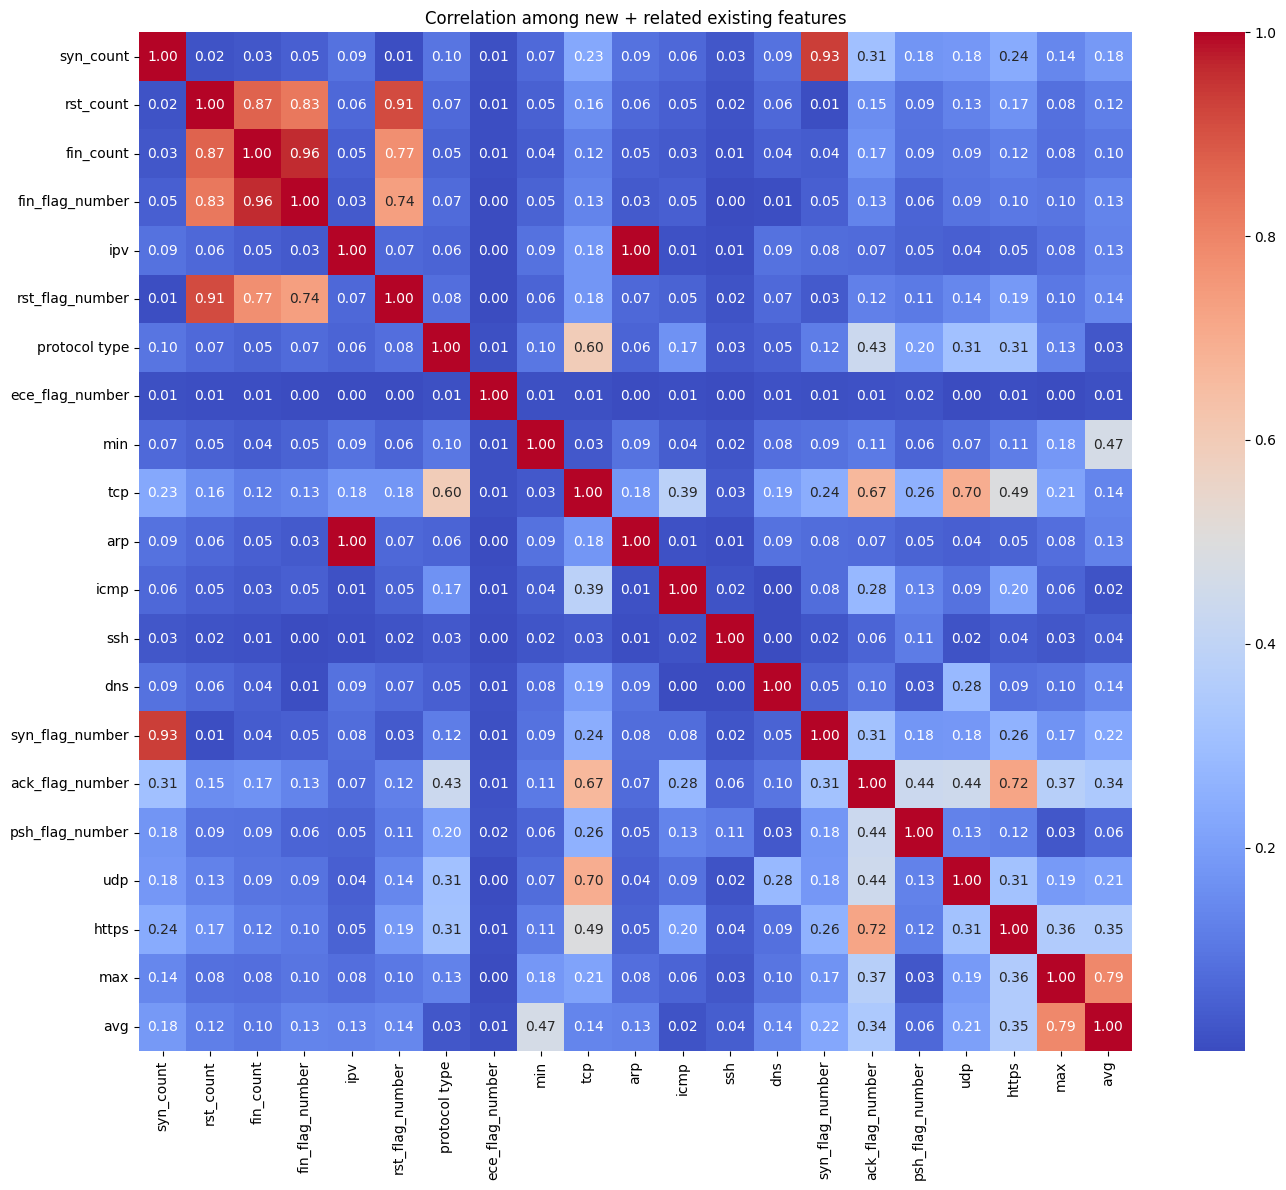

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Check correlation among just the NEW features + the existing ones they might overlap with
cols_to_check = [
    # New additions
    'syn_count', 'rst_count', 'fin_count', 'fin_flag_number',
    'ipv', 'rst_flag_number', 'protocol type', 'ece_flag_number',
    'min', 'tcp', 'arp', 'icmp', 'ssh', 'dns',
    # Existing ones likely to correlate with new
    'syn_flag_number', 'ack_flag_number', 'psh_flag_number',
    'udp', 'https', 'max', 'avg'
]

sample = df_raw[cols_to_check].sample(n=100000, random_state=42)
corr = sample.corr().abs()

# Print pairs with correlation > 0.85
print("Highly correlated pairs (> 0.85):")
printed = set()
for col1 in corr.columns:
    for col2 in corr.columns:
        if col1 != col2 and corr.loc[col1, col2] > 0.85:
            pair = tuple(sorted([col1, col2]))
            if pair not in printed:
                print(f"  {col1:<25} <-> {col2:<25}  r = {corr.loc[col1, col2]:.4f}")
                printed.add(pair)

# Heatmap for visual
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=cols_to_check, yticklabels=cols_to_check)
plt.title('Correlation among new + related existing features')
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

# Use df_raw already loaded — just reconfirm shape
print(f"df_raw shape: {df_raw.shape}")

# Final 25 features
final_features = [
    # Original 14 (syn_flag_number removed — redundant with syn_count)
    'number', 'https', 'ack_flag_number', 'time_to_live', 'ack_count',
    'psh_flag_number', 'header_length', 'iat', 'tot sum', 'rate',
    'max', 'avg', 'variance', 'udp',
    # New hard-class features (4 dropped due to correlation)
    'syn_count', 'rst_count', 'fin_count', 'protocol type',
    'ece_flag_number', 'min', 'tcp', 'arp', 'icmp', 'ssh', 'dns'
]

print(f"Final feature count: {len(final_features)}")

# Verify all features exist in df_raw
missing = [f for f in final_features if f not in df_raw.columns]
if missing:
    print(f"WARNING - missing columns: {missing}")
else:
    print("All features present in df_raw ✅")

# Scale
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_raw[final_features])

# Build final processed df
processed_df = pd.DataFrame(X_scaled, columns=final_features)
processed_df['Fine_Label']    = df_raw[label_col].values
processed_df['Superclass']    = df_raw['Superclass'].values
processed_df['Binary_Label']  = (df_raw['Superclass'] != 'Benign').astype(int).values

output_path = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid40-40)/preprocessed_v2_25features.csv'
processed_df.to_csv(output_path, index=False)

print(f"\n✅ Saved to: {output_path}")
print(f"📐 Shape: {processed_df.shape}")
print(f"\nBinary distribution:")
print(processed_df['Binary_Label'].value_counts().rename({0:'Benign', 1:'Attack'}).to_string())
print(f"\nSuperclass distribution:")
print(processed_df['Superclass'].value_counts().to_string())

df_raw shape: (2346628, 41)
Final feature count: 25
All features present in df_raw ✅

✅ Saved to: /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid40-40)/preprocessed_v2_25features.csv
📐 Shape: (2346628, 28)

Binary distribution:
Binary_Label
Attack    1320000
Benign    1026628

Superclass distribution:
Superclass
Benign         1026628
DDoS            480000
Web-based       240000
Recon           200000
DoS             160000
Mirai           120000
Spoofing         80000
Brute Force      40000


In [9]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score

# Use processed_df already in memory
X = processed_df[final_features]
y = processed_df['Binary_Label']
s = processed_df['Superclass']
fine = processed_df['Fine_Label']

X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, s, test_size=0.2, stratify=fine, random_state=42
)

# Train XGBoost on ALL 25 first to get ranked feature importance
xgb_full = XGBClassifier(n_estimators=100, max_depth=6, importance_type='gain',
                         verbosity=0, random_state=42, n_jobs=-1)
xgb_full.fit(X_train, y_train)

# Rank features by gain on the full model
gain_scores = pd.Series(
    xgb_full.get_booster().get_score(importance_type='gain')
).reindex(final_features, fill_value=0).sort_values(ascending=False)

print("Feature ranking by gain (full 25-feature model):")
for i, (feat, gain) in enumerate(gain_scores.items(), 1):
    print(f"  {i:>2}. {feat:<25} {gain:.2f}")

# Now evaluate at different feature set sizes: 10, 12, 15, 18, 20, 25
hard_classes = ['Recon', 'Spoofing', 'Web-based', 'Brute Force']
sizes = [10, 12, 15, 18, 20, 25]

print("\n" + "="*85)
print(f"{'Features':<10} {'Accuracy':<10} {'F1':<8} {'Recon':<10} {'Spoofing':<12} {'Web-based':<12} {'Brute Force'}")
print("="*85)

for n in sizes:
    top_n = gain_scores.index[:n].tolist()

    xgb_n = XGBClassifier(n_estimators=100, max_depth=6, verbosity=0,
                           random_state=42, n_jobs=-1)
    xgb_n.fit(X_train[top_n], y_train)
    y_pred = xgb_n.predict(X_test[top_n])

    acc = (y_pred == y_test).mean() * 100
    f1  = f1_score(y_test, y_pred)

    # Per hard-class detection rate
    results = pd.DataFrame({'Actual': s_test.values, 'Pred': y_pred})
    rates = {}
    for cls in hard_classes:
        sub = results[results['Actual'] == cls]
        rates[cls] = (sub['Pred'] == 1).mean() * 100 if len(sub) > 0 else 0

    print(f"  {n:<8} {acc:<10.2f} {f1:<8.4f} {rates['Recon']:<10.2f} {rates['Spoofing']:<12.2f} {rates['Web-based']:<12.2f} {rates['Brute Force']:.2f}")

print("="*85)

Feature ranking by gain (full 25-feature model):
   1. number                    15787.66
   2. https                     3160.82
   3. syn_count                 1339.47
   4. protocol type             1122.07
   5. icmp                      834.23
   6. arp                       764.26
   7. min                       744.98
   8. fin_count                 695.44
   9. max                       689.08
  10. psh_flag_number           541.37
  11. rst_count                 412.88
  12. iat                       328.04
  13. tcp                       325.75
  14. dns                       305.84
  15. rate                      284.19
  16. header_length             264.33
  17. time_to_live              255.69
  18. udp                       239.08
  19. ssh                       202.50
  20. ece_flag_number           179.29
  21. variance                  174.56
  22. ack_flag_number           126.07
  23. tot sum                   121.19
  24. avg                       60.38
  25. ack_c

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, recall_score, accuracy_score
from xgboost import XGBClassifier
import lightgbm as lgb
import time
import joblib
import os

# ── 1. LOAD RAW DATA ──────────────────────────────────────────────
print("🚀 Loading raw merged data...")
df_raw = pd.read_csv('/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid40-40)/merged.csv',
                     engine='c', low_memory=True)
float_cols = df_raw.select_dtypes(include=['float64']).columns
df_raw[float_cols] = df_raw[float_cols].astype('float32')
print(f"   Shape: {df_raw.shape}")

# ── 2. LABELS ─────────────────────────────────────────────────────
label_mapping = {
    'DDOS-ICMP_FLOOD': 'DDoS', 'DDOS-UDP_FLOOD': 'DDoS', 'DDOS-TCP_FLOOD': 'DDoS',
    'DDOS-PSHACK_FLOOD': 'DDoS', 'DDOS-SYN_FLOOD': 'DDoS', 'DDOS-RSTFINFLOOD': 'DDoS',
    'DDOS-SYNONYMOUSIP_FLOOD': 'DDoS', 'DDOS-UDP_FRAGMENTATION': 'DDoS', 'DDOS-ACK_FRAGMENTATION': 'DDoS',
    'DDOS-ICMP_FRAGMENTATION': 'DDoS', 'DDOS-HTTP_FLOOD': 'DDoS', 'DDOS-SLOWLORIS': 'DDoS',
    'DOS-UDP_FLOOD': 'DoS', 'DOS-TCP_FLOOD': 'DoS', 'DOS-SYN_FLOOD': 'DoS', 'DOS-HTTP_FLOOD': 'DoS',
    'MIRAI-GREETH_FLOOD': 'Mirai', 'MIRAI-UDPPLAIN': 'Mirai', 'MIRAI-GREIP_FLOOD': 'Mirai',
    'RECON-HOSTDISCOVERY': 'Recon', 'RECON-OSSCAN': 'Recon', 'RECON-PORTSCAN': 'Recon',
    'RECON-PINGSWEEP': 'Recon', 'VULNERABILITYSCAN': 'Recon',
    'SQLINJECTION': 'Web-based', 'BACKDOOR_MALWARE': 'Web-based', 'XSS': 'Web-based',
    'BROWSERHIJACKING': 'Web-based', 'COMMANDINJECTION': 'Web-based', 'UPLOADING_ATTACK': 'Web-based',
    'DNS_SPOOFING': 'Spoofing', 'MITM-ARPSPOOFING': 'Spoofing',
    'DICTIONARYBRUTEFORCE': 'Brute Force', 'BENIGN': 'Benign'
}

label_col = [c for c in df_raw.columns if c.lower() == 'label'][0]
df_raw['Superclass']    = df_raw[label_col].astype(str).str.strip().str.upper().map(label_mapping)
df_raw['Binary_Label']  = (df_raw['Superclass'] != 'Benign').astype(int)

# ── 3. CLEAN ──────────────────────────────────────────────────────
final_12 = ['number', 'https', 'syn_count', 'protocol type',
            'icmp', 'arp', 'min', 'fin_count',
            'max', 'psh_flag_number', 'rst_count', 'iat']

df_raw[final_12] = df_raw[final_12].replace([np.inf, -np.inf], np.nan)
for col in final_12:
    if df_raw[col].isnull().any():
        df_raw[col] = df_raw[col].fillna(df_raw[col].median())

# ── 4. SCALE & BUILD PROCESSED DF ────────────────────────────────
print("⚖️  Scaling features...")
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_raw[final_12])

processed_df = pd.DataFrame(X_scaled, columns=final_12)
processed_df['Fine_Label']   = df_raw[label_col].values
processed_df['Superclass']   = df_raw['Superclass'].values
processed_df['Binary_Label'] = df_raw['Binary_Label'].values

output_path = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid40-40)/preprocessed_v3_12features.csv'
processed_df.to_csv(output_path, index=False)
print(f"💾 Saved: {output_path}")
print(f"📐 Shape: {processed_df.shape}")

# ── 5. TRAIN/TEST SPLIT ───────────────────────────────────────────
X        = processed_df[final_12]
y        = processed_df['Binary_Label']
s        = processed_df['Superclass']
fine     = processed_df['Fine_Label']

X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, s, test_size=0.2, stratify=fine, random_state=42
)
print(f"\n✅ Train: {len(X_train):,}  |  Test: {len(X_test):,}")

# ── 6. EVALUATION FUNCTION ────────────────────────────────────────
def evaluate(model, name, X_test, y_test, s_test):
    start = time.time()
    y_pred = model.predict(X_test)
    elapsed = time.time() - start

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    acc  = accuracy_score(y_test, y_pred) * 100
    f1   = f1_score(y_test, y_pred)
    fnr  = (fn / (fn + tp)) * 100
    fpr  = (fp / (fp + tn)) * 100
    tput = len(X_test) / elapsed
    lat  = (elapsed / len(X_test)) * 1000

    # Per-superclass detection rates
    results = pd.DataFrame({'Actual': s_test.values, 'Pred': y_pred})
    breakdown = []
    for cat in sorted(results['Actual'].unique()):
        sub     = results[results['Actual'] == cat]
        total   = len(sub)
        correct = (sub['Pred'] == 0).sum() if cat == 'Benign' else (sub['Pred'] == 1).sum()
        rate    = (correct / total) * 100 if total > 0 else 0
        breakdown.append({'Superclass': cat, 'Samples': total,
                          'Detection Rate': f'{rate:.2f}%', 'Missed': total - correct})

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(pd.DataFrame(breakdown).sort_values('Samples', ascending=False).to_string(index=False))
    print(f"\n  Accuracy : {acc:.4f}%")
    print(f"  F1       : {f1:.4f}")
    print(f"  FNR      : {fnr:.3f}%   FPR: {fpr:.3f}%")
    print(f"  Latency  : {lat:.6f} ms/sample")
    print(f"  Throughput: {tput:,.0f} samples/sec")

    fname = f"{name.replace(' ','_').lower()}_v3.pkl"
    joblib.dump(model, fname)
    size_kb = os.path.getsize(fname) / 1024

    return {'Model': name, 'Features': 12, 'Accuracy (%)': round(acc, 4),
            'F1': round(f1, 4), 'FNR': f'{fnr:.3f}%', 'FPR': f'{fpr:.3f}%',
            'Latency (ms)': round(lat, 6), 'Throughput': round(tput, 2),
            'Size (KB)': round(size_kb, 2)}

# ── 7. TRAIN XGBoost + LightGBM ───────────────────────────────────
results = []

print("\n🚀 Training XGBoost...")
xgb = XGBClassifier(n_estimators=100, max_depth=6, importance_type='gain',
                    verbosity=0, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
results.append(evaluate(xgb, 'XGBoost', X_test, y_test, s_test))

print("\n🚀 Training LightGBM...")
lgbm = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1,
                           verbose=-1, random_state=42, n_jobs=-1)
lgbm.fit(X_train, y_train)
results.append(evaluate(lgbm, 'LightGBM', X_test, y_test, s_test))

# ── 8. COMPARISON vs OLD 15-FEATURE RESULTS ───────────────────────
print("\n" + "="*70)
print("SUMMARY — 12 features vs old 15-feature baseline")
print("="*70)
comparison = pd.DataFrame([
    # Old results from your previous notebook
    {'Model': 'XGBoost  (old 15-feat)',  'Features': 15, 'Accuracy (%)': 93.0662,
     'F1': 0.9365, 'FNR': '9.075%', 'FPR': '4.181%'},
    {'Model': 'LightGBM (old 15-feat)', 'Features': 15, 'Accuracy (%)': 92.5647,
     'F1': 0.9318, 'FNR': '9.723%', 'FPR': '4.494%'},
] + results)
print(comparison[['Model', 'Features', 'Accuracy (%)', 'F1', 'FNR', 'FPR']].to_string(index=False))

🚀 Loading raw merged data...
   Shape: (2346628, 40)
⚖️  Scaling features...
💾 Saved: /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid40-40)/preprocessed_v3_12features.csv
📐 Shape: (2346628, 15)

✅ Train: 1,877,302  |  Test: 469,326

🚀 Training XGBoost...

  XGBoost
 Superclass  Samples Detection Rate  Missed
     Benign   205326         96.83%    6499
       DDoS    96000        100.00%       4
  Web-based    48000         93.23%    3248
      Recon    40000         61.65%   15342
        DoS    32000         99.99%       3
      Mirai    24000        100.00%       0
   Spoofing    16000         81.59%    2945
Brute Force     8000         80.00%    1600

  Accuracy : 93.6843%
  F1       : 0.9420
  FNR      : 8.766%   FPR: 3.165%
  Latency  : 0.002043 ms/sample
  Throughput: 489,566 samples/sec

🚀 Training LightGBM...

  LightGBM
 Superclass  Samples Detection Rate  Missed
     Benign   205326         96.66%    6862
       DDoS    96000        100.00%       0
  Web

In [11]:
import pandas as pd
import numpy as np

# Analyse exactly which Recon subtypes are being missed
recon_mask = s_test == 'Recon'
recon_actual = y_test[recon_mask]
recon_pred   = xgb.predict(X_test[recon_mask])
recon_fine   = fine.iloc[X_test.index[recon_mask.values]]

results_recon = pd.DataFrame({
    'Fine_Label': recon_fine.values,
    'Pred': recon_pred
})

print("Recon subtype breakdown:")
print("="*55)
for subtype in results_recon['Fine_Label'].unique():
    sub   = results_recon[results_recon['Fine_Label'] == subtype]
    total = len(sub)
    detected = (sub['Pred'] == 1).sum()
    rate  = detected / total * 100
    print(f"  {subtype:<30} {detected:>5}/{total}  ({rate:.1f}%)")

# Also look at feature value distributions for missed vs detected Recon
print("\n\nFeature stats: MISSED Recon vs DETECTED Recon vs Benign")
print("="*75)

recon_df = X_test[recon_mask].copy()
recon_df['Pred'] = recon_pred

missed   = recon_df[recon_df['Pred'] == 0]   # classified as Benign — bad
detected = recon_df[recon_df['Pred'] == 1]   # correctly caught
benign   = X_test[s_test == 'Benign'].sample(n=5000, random_state=42)

for feat in ['syn_count', 'rst_count', 'fin_count', 'number', 'protocol type', 'icmp', 'arp']:
    m_med = missed[feat].median()
    d_med = detected[feat].median()
    b_med = benign[feat].median()
    print(f"  {feat:<20} missed={m_med:>8.3f}  detected={d_med:>8.3f}  benign={b_med:>8.3f}")

Recon subtype breakdown:
  VULNERABILITYSCAN               3291/8000  (41.1%)
  RECON-PINGSWEEP                 7556/8000  (94.5%)
  RECON-PORTSCAN                  4537/8000  (56.7%)
  RECON-HOSTDISCOVERY             5903/8000  (73.8%)
  RECON-OSSCAN                    3371/8000  (42.1%)


Feature stats: MISSED Recon vs DETECTED Recon vs Benign
  syn_count            missed=   0.000  detected=   1.216  benign=   0.000
  rst_count            missed=   0.000  detected=   0.000  benign=   0.000
  fin_count            missed=   0.000  detected=   0.000  benign=   0.000
  number               missed=   0.000  detected=   0.000  benign=   0.000
  protocol type        missed=   0.000  detected=   0.000  benign=   0.000
  icmp                 missed=   0.000  detected=   0.000  benign=   0.000
  arp                  missed=   0.000  detected=   0.000  benign=   0.000


Threshold    Accuracy   F1       FPR      Recon    Spoofing   Web-based    Brute Force
  0.5        93.68      0.9420   3.17     61.65    81.59      93.23        80.00
  0.45       93.62      0.9420   4.25     64.75    82.62      94.10        81.54
  0.4        93.45      0.9409   5.58     67.89    83.55      94.84        83.19
  0.35       93.18      0.9391   7.14     71.24    84.53      95.50        85.02
  0.3        92.70      0.9356   9.25     74.83    85.74      96.14        86.80
  0.25       92.00      0.9303   11.85    78.30    87.09      96.71        88.71
  0.2        90.79      0.9213   15.70    82.10    88.91      97.32        90.35


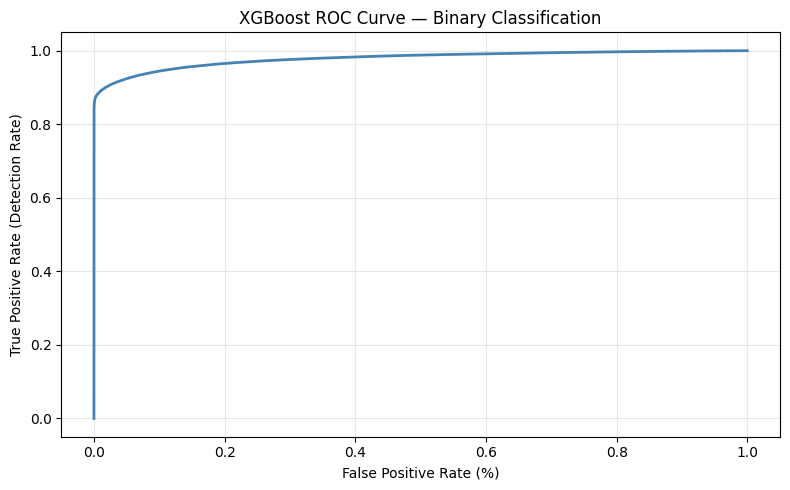

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

y_proba = xgb.predict_proba(X_test)[:, 1]

# Overall ROC
fpr_arr, tpr_arr, thresholds = roc_curve(y_test, y_proba)

# Per-class detection rate at different thresholds
thresholds_to_try = [0.5, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]
hard_classes = ['Recon', 'Spoofing', 'Web-based', 'Brute Force']

print(f"{'Threshold':<12} {'Accuracy':<10} {'F1':<8} {'FPR':<8} {'Recon':<8} {'Spoofing':<10} {'Web-based':<12} {'Brute Force'}")
print("="*85)

results_df = pd.DataFrame({'Actual_s': s_test.values, 'Actual_y': y_test.values, 'Proba': y_proba})

for thresh in thresholds_to_try:
    y_pred_t = (y_proba >= thresh).astype(int)

    acc = accuracy_score(y_test, y_pred_t) * 100
    f1  = f1_score(y_test, y_pred_t)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    fpr_val = fp / (fp + tn) * 100

    rates = {}
    for cls in hard_classes:
        sub = results_df[results_df['Actual_s'] == cls]
        rates[cls] = ((sub['Proba'] >= thresh).sum() / len(sub)) * 100

    print(f"  {thresh:<10} {acc:<10.2f} {f1:<8.4f} {fpr_val:<8.2f} {rates['Recon']:<8.2f} {rates['Spoofing']:<10.2f} {rates['Web-based']:<12.2f} {rates['Brute Force']:.2f}")

# Plot ROC
plt.figure(figsize=(8, 5))
plt.plot(fpr_arr, tpr_arr, color='steelblue', lw=2)
plt.xlabel('False Positive Rate (%)')
plt.ylabel('True Positive Rate (Detection Rate)')
plt.title('XGBoost ROC Curve — Binary Classification')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

THRESHOLD = 0.35

def full_evaluate(model, name, X_test, y_test, s_test, threshold=0.5):
    proba  = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    acc = accuracy_score(y_test, y_pred) * 100
    f1  = f1_score(y_test, y_pred)
    fnr = fn / (fn + tp) * 100
    fpr = fp / (fp + tn) * 100

    results = pd.DataFrame({'Actual': s_test.values, 'Pred': y_pred})
    breakdown = []
    rates = {}
    for cat in sorted(results['Actual'].unique()):
        sub     = results[results['Actual'] == cat]
        total   = len(sub)
        correct = (sub['Pred'] == 0).sum() if cat == 'Benign' else (sub['Pred'] == 1).sum()
        rate    = correct / total * 100
        rates[cat] = rate
        breakdown.append({'Superclass': cat, 'Samples': total,
                          'Detection Rate': f'{rate:.2f}%', 'Missed': total - correct})

    print(f"\n{'='*60}")
    print(f"  {name} | threshold={threshold}")
    print(f"{'='*60}")
    print(pd.DataFrame(breakdown).sort_values('Samples', ascending=False).to_string(index=False))
    print(f"\n  Accuracy : {acc:.4f}%  |  F1: {f1:.4f}")
    print(f"  FNR      : {fnr:.3f}%  |  FPR: {fpr:.3f}%")

    return {
        'Model': name, 'Threshold': threshold,
        'Accuracy': round(acc, 4), 'F1': round(f1, 4),
        'FNR': f'{fnr:.3f}%', 'FPR': f'{fpr:.3f}%',
        'Recon': f"{rates.get('Recon', 0):.2f}%",
        'Spoofing': f"{rates.get('Spoofing', 0):.2f}%",
        'Web-based': f"{rates.get('Web-based', 0):.2f}%",
        'Brute Force': f"{rates.get('Brute Force', 0):.2f}%",
    }

# Run all 4 combinations — both models, both thresholds
all_results = []
for model, name in [(xgb, 'XGBoost'), (lgbm, 'LightGBM')]:
    for thresh in [0.5, THRESHOLD]:
        r = full_evaluate(model, name, X_test, y_test, s_test, threshold=thresh)
        all_results.append(r)

# Clean summary table
print("\n" + "="*95)
print("FULL COMPARISON")
print("="*95)
print(pd.DataFrame(all_results)[
    ['Model', 'Threshold', 'Accuracy', 'F1', 'FNR', 'FPR',
     'Recon', 'Spoofing', 'Web-based', 'Brute Force']
].to_string(index=False))


  XGBoost | threshold=0.5
 Superclass  Samples Detection Rate  Missed
     Benign   205326         96.83%    6499
       DDoS    96000        100.00%       4
  Web-based    48000         93.23%    3248
      Recon    40000         61.65%   15342
        DoS    32000         99.99%       3
      Mirai    24000        100.00%       0
   Spoofing    16000         81.59%    2945
Brute Force     8000         80.00%    1600

  Accuracy : 93.6843%  |  F1: 0.9420
  FNR      : 8.766%  |  FPR: 3.165%

  XGBoost | threshold=0.35
 Superclass  Samples Detection Rate  Missed
     Benign   205326         92.86%   14658
       DDoS    96000        100.00%       2
  Web-based    48000         95.50%    2158
      Recon    40000         71.24%   11504
        DoS    32000        100.00%       0
      Mirai    24000        100.00%       0
   Spoofing    16000         84.53%    2475
Brute Force     8000         85.02%    1198

  Accuracy : 93.1828%  |  F1: 0.9391
  FNR      : 6.567%  |  FPR: 7.139%

  Li

In [15]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

THRESHOLD = 0.35

# ── Sample weights: penalize hard classes more ────────────────────
# Base weight = 1 for everything, bump up the classes the model struggles with
weight_map = {
    'Benign': 1.0,
    'DDoS': 1.0,
    'DoS': 1.0,
    'Mirai': 1.0,
    'Recon': 3.0,       # hardest — triple penalty for misses
    'Spoofing': 2.0,
    'Web-based': 1.5,
    'Brute Force': 2.0,
}
sample_weights = s_train.map(weight_map).values

def full_evaluate(model, name, X_test, y_test, s_test, threshold=0.5):
    proba  = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    acc = accuracy_score(y_test, y_pred) * 100
    f1  = f1_score(y_test, y_pred)
    fnr = fn / (fn + tp) * 100
    fpr = fp / (fp + tn) * 100
    results = pd.DataFrame({'Actual': s_test.values, 'Pred': y_pred})
    breakdown = []
    rates = {}
    for cat in sorted(results['Actual'].unique()):
        sub     = results[results['Actual'] == cat]
        total   = len(sub)
        correct = (sub['Pred'] == 0).sum() if cat == 'Benign' else (sub['Pred'] == 1).sum()
        rate    = correct / total * 100
        rates[cat] = rate
        breakdown.append({'Superclass': cat, 'Samples': total,
                          'Detection Rate': f'{rate:.2f}%', 'Missed': total - correct})
    print(f"\n{'='*60}")
    print(f"  {name} | threshold={threshold}")
    print(f"{'='*60}")
    print(pd.DataFrame(breakdown).sort_values('Samples', ascending=False).to_string(index=False))
    print(f"\n  Accuracy : {acc:.4f}%  |  F1: {f1:.4f}")
    print(f"  FNR      : {fnr:.3f}%  |  FPR: {fpr:.3f}%")
    return {'Model': name, 'Threshold': threshold,
            'Accuracy': round(acc, 4), 'F1': round(f1, 4),
            'FNR': f'{fnr:.3f}%', 'FPR': f'{fpr:.3f}%',
            'Recon': f"{rates.get('Recon',0):.2f}%",
            'Spoofing': f"{rates.get('Spoofing',0):.2f}%",
            'Web-based': f"{rates.get('Web-based',0):.2f}%",
            'Brute Force': f"{rates.get('Brute Force',0):.2f}%"}

# ── Tuned XGBoost ─────────────────────────────────────────────────
print("🚀 Training tuned XGBoost...")
xgb_tuned = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    verbosity=0,
    random_state=42,
    n_jobs=-1
)
xgb_tuned.fit(X_train, y_train, sample_weight=sample_weights)

# ── Tuned LightGBM ────────────────────────────────────────────────
print("🚀 Training tuned LightGBM...")
lgb_tuned = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    verbose=-1,
    random_state=42,
    n_jobs=-1
)
lgb_tuned.fit(X_train, y_train, sample_weight=sample_weights)

# ── Evaluate all: old vs tuned, both thresholds ───────────────────
all_results = []
for model, name in [(xgb, 'XGBoost  (baseline 12f)'),
                    (xgb_tuned, 'XGBoost  (tuned+weighted)'),
                    (lgbm, 'LightGBM (baseline 12f)'),
                    (lgb_tuned, 'LightGBM (tuned+weighted)')]:
    for thresh in [0.5, THRESHOLD]:
        r = full_evaluate(model, name, X_test, y_test, s_test, threshold=thresh)
        all_results.append(r)

print("\n" + "="*100)
print("FULL COMPARISON")
print("="*100)
print(pd.DataFrame(all_results)[
    ['Model', 'Threshold', 'Accuracy', 'F1', 'FNR', 'FPR',
     'Recon', 'Spoofing', 'Web-based', 'Brute Force']
].to_string(index=False))

🚀 Training tuned XGBoost...
🚀 Training tuned LightGBM...

  XGBoost  (baseline 12f) | threshold=0.5
 Superclass  Samples Detection Rate  Missed
     Benign   205326         96.83%    6499
       DDoS    96000        100.00%       4
  Web-based    48000         93.23%    3248
      Recon    40000         61.65%   15342
        DoS    32000         99.99%       3
      Mirai    24000        100.00%       0
   Spoofing    16000         81.59%    2945
Brute Force     8000         80.00%    1600

  Accuracy : 93.6843%  |  F1: 0.9420
  FNR      : 8.766%  |  FPR: 3.165%

  XGBoost  (baseline 12f) | threshold=0.35
 Superclass  Samples Detection Rate  Missed
     Benign   205326         92.86%   14658
       DDoS    96000        100.00%       2
  Web-based    48000         95.50%    2158
      Recon    40000         71.24%   11504
        DoS    32000        100.00%       0
      Mirai    24000        100.00%       0
   Spoofing    16000         84.53%    2475
Brute Force     8000         85.02